In [4]:
import pm4py
import json
import os
import pandas as pd
from collections import defaultdict, Counter
from IPython.display import display
from pm4py.algo.discovery.ocel.ocdfg import algorithm as ocdfg_algorithm
from pm4py.visualization.ocel.ocdfg import visualizer as ocdfg_visualizer

LOG_DIR = "role_logs"
FULL_LOG_PATH = "commitizen_role_annotated.json"
SMALL_LOG_THRESHOLD = 50   # warn if a role log has fewer events
SINGLE_ACT_THRESHOLD = 0.95  # treat role as single-activity if top act >= 95 %

role_files = sorted([
    f for f in os.listdir(LOG_DIR)
    if f.startswith("ocel_") and f.endswith(".json")
])

# Load full log once for co-activity analysis
with open(FULL_LOG_PATH) as fh:
    full_log = json.load(fh)
# Pre-build object-id → type map from full log
full_obj_type = {o["id"]: o["type"] for o in full_log["objects"]}
# Pre-build object-id → set of event types (co-activities) map
_obj_to_events = defaultdict(list)
for _e in full_log["events"]:
    for _rel in _e.get("relationships", []):
        _obj_to_events[_rel["objectId"]].append(_e["type"])

print("Role logs found:")
for fname in role_files:
    path = os.path.join(LOG_DIR, fname)
    with open(path) as fh:
        d = json.load(fh)
    print(f"  {fname:40s}  events={len(d['events']):5d}  objects={len(d['objects']):5d}")
print(f"\nFull log loaded: {len(full_log['events'])} events, {len(full_log['objects'])} objects")


Role logs found:
  ocel_bot.json                             events= 3394  objects= 1055
  ocel_contributor.json                     events=  236  objects=  495
  ocel_devops_engineer.json                 events=   15  objects=   39
  ocel_feature_developer.json               events=  100  objects=  212
  ocel_issue_reporter.json                  events=16037  objects= 1863
  ocel_maintainer.json                      events= 2149  objects= 4386
  ocel_quality_engineer.json                events=  194  objects=  395
  ocel_technical_writer.json                events=   71  objects=  194

Full log loaded: 21488 events, 6534 objects


In [5]:
# ── Helper functions ─────────────────────────────────────────────────────────

def activity_frequency(data: dict) -> pd.DataFrame:
    """Count events per activity, sorted by frequency."""
    counts = defaultdict(int)
    for event in data["events"]:
        counts[event["type"]] += 1
    total = sum(counts.values())
    df = pd.DataFrame(
        [{"activity": k, "count": v, "share_%": round(100 * v / total, 1)}
         for k, v in sorted(counts.items(), key=lambda x: -x[1])]
    )
    return df


def is_single_activity(data: dict, threshold: float = SINGLE_ACT_THRESHOLD) -> bool:
    """Return True if one activity dominates >= threshold of all events."""
    counts = Counter(e["type"] for e in data["events"])
    if not counts:
        return True
    top_share = counts.most_common(1)[0][1] / sum(counts.values())
    return top_share >= threshold


def object_type_profile(data: dict) -> pd.DataFrame:
    """Count distinct objects per type that this role's events touch."""
    obj_type = {obj["id"]: obj["type"] for obj in data["objects"]}
    touched = {rel["objectId"]
               for event in data["events"]
               for rel in event.get("relationships", [])}
    counts = Counter(obj_type.get(oid, "unknown") for oid in touched)
    df = pd.DataFrame(
        [{"object_type": k, "distinct_objects": v}
         for k, v in sorted(counts.items(), key=lambda x: -x[1])]
    )
    return df


def co_activity_analysis(data: dict) -> pd.DataFrame:
    """
    For each object touched by this role, collect all activities that
    appear on that object in the full log.  Shows what else happens
    on the same issues/PRs/tasks that this role committed to.
    """
    touched = {rel["objectId"]
               for event in data["events"]
               for rel in event.get("relationships", [])}
    counts = Counter()
    for oid in touched:
        for act in _obj_to_events.get(oid, []):
            counts[act] += 1
    total = sum(counts.values())
    df = pd.DataFrame(
        [{"activity": k, "count": v, "share_%": round(100 * v / total, 1)}
         for k, v in sorted(counts.items(), key=lambda x: -x[1])]
    )
    return df


def object_type_cooccurrence(data: dict) -> pd.DataFrame:
    """
    For each activity, count how many events involve each object type.
    Returns a (activity x object_type) frequency matrix.
    """
    obj_type = {obj["id"]: obj["type"] for obj in data["objects"]}
    rows = []
    for event in data["events"]:
        activity = event["type"]
        types_seen = {
            obj_type.get(rel["objectId"], "unknown")
            for rel in event.get("relationships", [])
        }
        for t in types_seen:
            rows.append({"activity": activity, "object_type": t})
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    return (
        df.groupby(["activity", "object_type"])
        .size()
        .unstack(fill_value=0)
        .sort_values(by=df["object_type"].unique().tolist(), ascending=False)
    )


def ocdfg_threshold(n_events: int) -> int:
    """Dynamic edge/activity threshold: ~2 % of events, minimum 1."""
    return max(1, n_events // 50)


print("Helpers defined.")


Helpers defined.



══════════════════════════════════════════════════════════════════════
  ROLE: BOT
══════════════════════════════════════════════════════════════════════
  Events: 3394   Objects: 1055

--- 1. Activity Frequency ---


,activity,count,share_%
0,labeled,1151,33.9
1,commented,915,27.0
2,review_requested,708,20.9
3,created,370,10.9
4,head_ref_force_pushed,77,2.3
5,head_ref_deleted,76,2.2
6,closed,44,1.3
7,cross_referenced,42,1.2
8,referenced,6,0.2
9,unlabeled,4,0.1



--- 2. Object-Type Co-occurrence per Activity ---


object_type,issue,user
activity,,
labeled,1151,1151
commented,915,915
review_requested,708,708
created,370,370
head_ref_force_pushed,77,77
head_ref_deleted,76,76
closed,44,44
cross_referenced,42,42
referenced,6,6



--- 3. OC-DFG ---
  Using frequency threshold: 67
  Saved → role_logs/ocdfg_bot.png


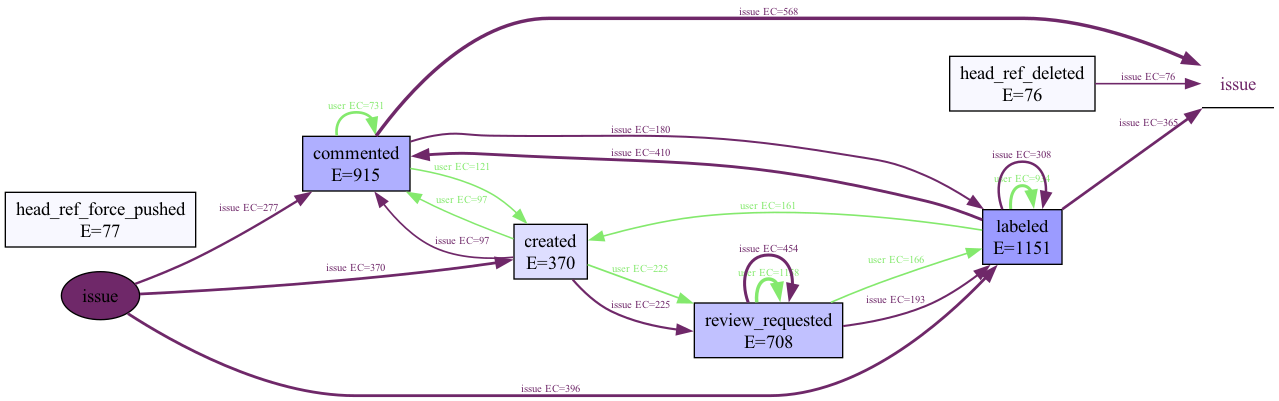


══════════════════════════════════════════════════════════════════════
  ROLE: CONTRIBUTOR
══════════════════════════════════════════════════════════════════════
  Events: 236   Objects: 495
  ℹ  Single-activity role (dominant: 'committed'). Showing object profile and co-activity analysis instead of DFG.

--- 1. Object-Type Profile (distinct objects touched) ---


,object_type,distinct_objects
0,commit,236
1,issue,109
2,task,84
3,user,66



--- 2. Co-Activity Analysis (all activities on same objects, full log) ---


,activity,count,share_%
0,committed,947,32.4
1,commented,455,15.6
2,head_ref_force_pushed,175,6.0
3,mentioned,167,5.7
4,subscribed,165,5.6
5,reviewed,156,5.3
6,labeled,147,5.0
7,review_requested,134,4.6
8,closed,111,3.8
9,created,109,3.7



══════════════════════════════════════════════════════════════════════
  ROLE: DEVOPS_ENGINEER
══════════════════════════════════════════════════════════════════════
  Events: 15   Objects: 39
  ⚠  Small log (15 events < threshold 50). Results may not be statistically meaningful.
  ℹ  Single-activity role (dominant: 'committed'). Showing object profile and co-activity analysis instead of DFG.

--- 1. Object-Type Profile (distinct objects touched) ---


...


══════════════════════════════════════════════════════════════════════
  ROLE: ISSUE_REPORTER
══════════════════════════════════════════════════════════════════════
  Events: 16037   Objects: 1863

--- 1. Activity Frequency ---


,activity,count,share_%
0,commented,2900,18.1
1,review_requested,1639,10.2
2,closed,1432,8.9
3,reviewed,1120,7.0
4,created,1089,6.8
5,mentioned,994,6.2
6,subscribed,962,6.0
7,head_ref_force_pushed,946,5.9
8,labeled,891,5.6
9,merged,876,5.5



--- 2. Object-Type Co-occurrence per Activity ---


object_type,issue,user
activity,,
commented,2900,2900
review_requested,1639,1639
closed,1432,1432
reviewed,1120,1120
created,1089,1089
mentioned,994,994
subscribed,962,962
head_ref_force_pushed,946,946
labeled,891,891



--- 3. OC-DFG ---
  Using frequency threshold: 320
  Saved → role_logs/ocdfg_issue_reporter.png


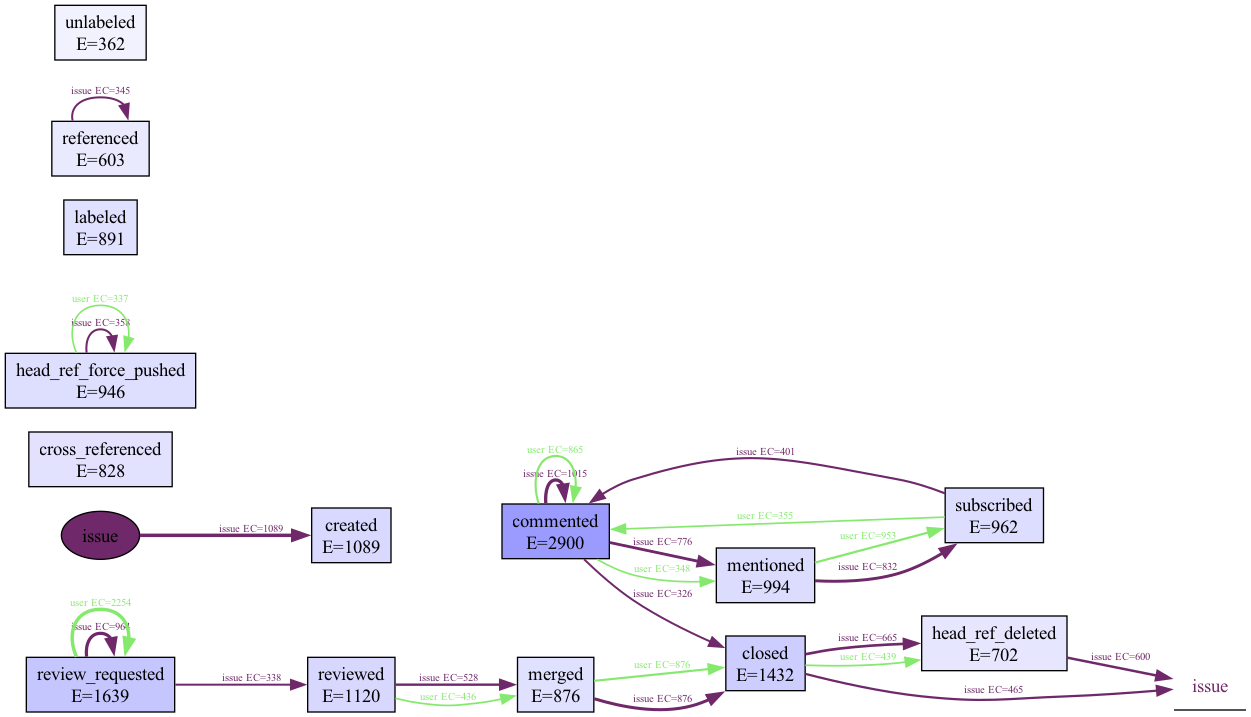


══════════════════════════════════════════════════════════════════════
  ROLE: MAINTAINER
══════════════════════════════════════════════════════════════════════
  Events: 2149   Objects: 4386
  ℹ  Single-activity role (dominant: 'committed'). Showing object profile and co-activity analysis instead of DFG.

--- 1. Object-Type Profile (distinct objects touched) ---


,object_type,distinct_objects
0,commit,2149
1,task,1392
2,issue,837
3,user,8



--- 2. Co-Activity Analysis (all activities on same objects, full log) ---


,activity,count,share_%
0,committed,7968,43.6
1,commented,1520,8.3
2,review_requested,1424,7.8
3,labeled,1126,6.2
4,closed,841,4.6
5,created,837,4.6
6,reviewed,832,4.6
7,head_ref_force_pushed,767,4.2
8,head_ref_deleted,722,4.0
9,merged,713,3.9



══════════════════════════════════════════════════════════════════════
  ROLE: QUALITY_ENGINEER
══════════════════════════════════════════════════════════════════════
  Events: 194   Objects: 395
  ℹ  Single-activity role (dominant: 'committed'). Showing object profile and co-activity analysis instead of DFG.

--- 1. Object-Type Profile (distinct objects touched) ---


...


══════════════════════════════════════════════════════════════════════
  ROLE: TECHNICAL_WRITER
══════════════════════════════════════════════════════════════════════
  Events: 71   Objects: 194
  ℹ  Single-activity role (dominant: 'committed'). Showing object profile and co-activity analysis instead of DFG.

--- 1. Object-Type Profile (distinct objects touched) ---


,object_type,distinct_objects
0,commit,71
1,task,63
2,issue,37
3,user,23



--- 2. Co-Activity Analysis (all activities on same objects, full log) ---


,activity,count,share_%
0,committed,313,41.1
1,commented,102,13.4
2,reviewed,56,7.4
3,closed,39,5.1
4,created,37,4.9
5,merged,34,4.5
6,mentioned,33,4.3
7,subscribed,33,4.3
8,review_requested,27,3.5
9,labeled,24,3.2



══════════════════════════════════════════════════════════════════════
Done.


In [6]:
# ── Main analysis loop ───────────────────────────────────────────────────────

for fname in role_files:
    role = fname.replace("ocel_", "").replace(".json", "")
    path = os.path.join(LOG_DIR, fname)

    with open(path) as fh:
        data = json.load(fh)

    n_events  = len(data["events"])
    n_objects = len(data["objects"])
    single_act = is_single_activity(data)

    print("\n" + "═" * 70)
    print(f"  ROLE: {role.upper()}")
    print("═" * 70)
    print(f"  Events: {n_events}   Objects: {n_objects}")

    if n_events < SMALL_LOG_THRESHOLD:
        print(f"  ⚠  Small log ({n_events} events < threshold {SMALL_LOG_THRESHOLD}). "
              "Results may not be statistically meaningful.")

    # ── Branch: single-activity roles vs diverse roles ───────────────────────
    if single_act:
        dominant = Counter(e["type"] for e in data["events"]).most_common(1)[0][0]
        print(f"  ℹ  Single-activity role (dominant: '{dominant}'). "
              "Showing object profile and co-activity analysis instead of DFG.")

        # ── 1. Object-type profile ───────────────────────────────────────────
        print("\n--- 1. Object-Type Profile (distinct objects touched) ---")
        df_profile = object_type_profile(data)
        display(df_profile)

        # ── 2. Co-activity analysis ──────────────────────────────────────────
        print("\n--- 2. Co-Activity Analysis (all activities on same objects, full log) ---")
        df_coact = co_activity_analysis(data)
        if not df_coact.empty:
            display(df_coact)
        else:
            print("  (no co-activities found)")

    else:
        # ── 1. Activity frequency ────────────────────────────────────────────
        print("\n--- 1. Activity Frequency ---")
        df_freq = activity_frequency(data)
        display(df_freq)

        # ── 2. Object-type co-occurrence per activity ────────────────────────
        print("\n--- 2. Object-Type Co-occurrence per Activity ---")
        df_cooc = object_type_cooccurrence(data)
        if not df_cooc.empty:
            display(df_cooc)
        else:
            print("  (no relationships found)")

        # ── 3. OC-DFG discovery + save ───────────────────────────────────────
        print("\n--- 3. OC-DFG ---")
        ocel_role = pm4py.read_ocel2_json(path)
        threshold  = ocdfg_threshold(n_events)
        print(f"  Using frequency threshold: {threshold}")

        ocdfg_obj = ocdfg_algorithm.apply(ocel_role)
        viz_params = {
            "annotation": "frequency",
            "act_threshold":  threshold,
            "edge_threshold": threshold,
            "performance_aggregation": "mean",
        }
        graph = ocdfg_visualizer.apply(ocdfg_obj, parameters=viz_params)

        out_path = os.path.join(LOG_DIR, f"ocdfg_{role}.png")
        ocdfg_visualizer.save(graph, out_path)
        print(f"  Saved → {out_path}")
        ocdfg_visualizer.view(graph)

print("\n" + "═" * 70)
print("Done.")
